# DNN + SELU + AlphaDropout 正则化神经网络（FashionMNIST）

> 本节在 DNN 的基础上引入 **AlphaDropout** 正则化技术，与 SELU 激活函数配合使用以防止过拟合。  
>
> **AlphaDropout 原理：**  
> - 普通 Dropout 随机将神经元输出置零，会破坏 SELU 的自归一化特性（输出均值和方差改变）。  
> - AlphaDropout 在置零的同时进行线性变换（缩放和平移），使得 dropout 后的输出仍然保持均值约为 0、方差约为 1，从而与 SELU 的自归一化特性完美兼容。  
> - **推理阶段**：AlphaDropout 自动将 `p` 置为 0（即不 dropout），通过 `model.eval()` 触发。  
> 论文：*Self-Normalizing Neural Networks*（Klambauer et al., 2017）

---

## 一、环境准备与库导入

In [1]:
import matplotlib as mpl          # 导入 matplotlib 绘图库，用于学习曲线可视化
import matplotlib.pyplot as plt   # 导入 pyplot 子模块，别名 plt，提供类 MATLAB 绘图接口
%matplotlib inline                 
# Jupyter 魔法命令：图表直接内嵌在 Notebook 输出区
import numpy as np                 # 导入 numpy 数值计算库，别名 np；高效多维数组运算
import sklearn                     # 导入 scikit-learn（用于 accuracy_score 计算准确率）
import pandas as pd                # 导入 pandas，别名 pd；整理训练/验证指标记录
import os                          # 导入 os：文件路径操作，创建 checkpoints 目录
import sys                         # 导入 sys：获取 Python 版本信息
import time                        # 导入 time（备用），可用于计时
from tqdm import tqdm         # 导入 tqdm 进度条，auto 模式适配 Jupyter/终端
import torch                       # 导入 PyTorch 深度学习框架
import torch.nn as nn              # 导入 nn 模块：Linear、ReLU、AlphaDropout 等层及损失函数
import torch.nn.functional as F    # 导入函数式 API：激活函数等无状态操作

print(sys.version_info)                        # 打印 Python 版本信息
for module in mpl, np, pd, sklearn, torch:    # 遍历主要依赖库
    print(module.__name__, module.__version__) # __name__: 库名；__version__: 版本号

# 优先使用 GPU（cuda:0），否则使用 CPU
# torch.device(str) -> torch.device：表示运算设备对象
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)  # 打印当前设备


sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 二、加载与预处理 FashionMNIST 数据集

**数据集划分策略：**

| 子集 | 来源 | 样本数 | 用途 |
|------|------|--------|------|
| 训练集（train） | 官方 train，`random_split` 80% | 48000 | 梯度更新，权重学习 |
| 验证集（val）   | 官方 train，`random_split` 20% | 12000 | 超参调优，早停监控 |
| 测试集（test）  | 官方 test，独立保留             | 10000 | 最终泛化性能评估   |

> 验证集从训练集中切分（`random_split`，固定种子 42），官方测试集严格保留，
> 避免超参搜索过程中信息泄露到测试集，保证测试指标真实反映泛化能力。

In [2]:
from torchvision import datasets                    # 导入 torchvision 数据集模块，内含 FashionMNIST 等
from torchvision.transforms import ToTensor         # ToTensor：将 PIL Image 转为 FloatTensor，像素归一化到 [0,1]
from torch.utils.data import random_split           # random_split：将 Dataset 随机切分为若干子集

# ─── 原始数据加载 ───────────────────────────────────────────────────────────────
# FashionMNIST：10 类服装图像，28×28 灰度图，官方提供 train=60000，test=10000
full_train_ds = datasets.FashionMNIST(
    root="data",          # str: 数据存储根目录，不存在时自动创建
    train=True,           # bool: True 加载官方训练集（60000 张）
    download=True,        # bool: 本地缺失时自动从网络下载
    transform=ToTensor()  # callable: 将 PIL Image 转为 FloatTensor，shape=[1,28,28]，像素归一化到 [0,1]
)

test_ds = datasets.FashionMNIST(
    root="data",          # str: 与训练集共用目录
    train=False,          # bool: False 加载官方测试集（10000 张），保留为最终评估集
    download=True,        # bool: 本地缺失时自动下载
    transform=ToTensor()  # callable: 同训练集预处理，保证输入分布一致
)

# ─── 切分训练集 → 训练子集 + 验证子集 ──────────────────────────────────────────
# 策略：从 60000 张官方训练数据中划出 20%（12000 张）作为验证集
#       官方测试集（10000 张）严格保留，仅在训练结束后做最终泛化评估
TRAIN_SIZE = 48000   # int: 训练子集样本数（占原训练集 80%）
VAL_SIZE   = 12000   # int: 验证子集样本数（占原训练集 20%）

# random_split(dataset, lengths, generator=None)
#   dataset  : Dataset — 待切分的完整数据集
#   lengths  : list[int] — 各子集的样本数，之和必须等于 len(dataset)
#   generator: torch.Generator — 可选，控制随机种子以保证可复现
#   返回值   : list[Subset]，每个 Subset 包含对应索引
train_ds, val_ds = random_split(
    full_train_ds,
    [TRAIN_SIZE, VAL_SIZE],
    generator=torch.Generator().manual_seed(42)   # 固定种子，保证每次切分结果一致
)

print(f"训练集大小：{len(train_ds)}")   # 输出：训练集大小：48000
print(f"验证集大小：{len(val_ds)}")     # 输出：验证集大小：12000
print(f"测试集大小：{len(test_ds)}")    # 输出：测试集大小：10000

# ─── 构建 DataLoader ────────────────────────────────────────────────────────────
# DataLoader(dataset, batch_size, shuffle, num_workers, ...)
#   dataset    : Dataset/Subset — 数据源
#   batch_size : int — 每个 mini-batch 的样本数
#   shuffle    : bool — 训练集需打乱顺序；验证/测试集保持固定顺序
#   返回值     : 可迭代对象，每次迭代返回 (Tensor[B,C,H,W], Tensor[B])
train_loader = torch.utils.data.DataLoader(
    train_ds,             # Subset: 训练子集（48000 张）
    batch_size=64,        # int: 每批 64 张图像
    shuffle=True          # bool: 每 epoch 随机打乱，避免模型记忆样本顺序
)
val_loader = torch.utils.data.DataLoader(
    val_ds,               # Subset: 验证子集（12000 张）
    batch_size=128,        # int: 验证批大小，与训练保持一致
    shuffle=False         # bool: 验证集保持固定顺序，结果可重复
)
test_loader = torch.utils.data.DataLoader(
    test_ds,              # Dataset: 官方测试集（10000 张），仅最终评估使用
    batch_size=128,        # int: 测试批大小
    shuffle=False         # bool: 测试集保持固定顺序
)

训练集大小：48000
验证集大小：12000
测试集大小：10000


In [3]:
from torchvision.transforms import Normalize  # 导入 Normalize 变换：对张量按通道做标准化，公式：output = (input - mean) / std

# 计算训练集各通道的均值和标准差（用于后续标准化）
# 参数 ds: Dataset，包含 (img: Tensor[C,H,W], label: int) 的可迭代对象
# 返回值: (mean: Tensor[C], std: Tensor[C])，C 为通道数（灰度图 C=1）
def cal_mean_std(ds):
    mean = 0.          # 累计均值，初始化为 0.0（float）
    std = 0.           # 累计标准差，初始化为 0.0（float）
    for img, _ in ds:  # 遍历数据集，img: Tensor[C,H,W]；_ 表示忽略标签
        mean += img.mean(dim=(1, 2))  # 对 H、W 维度取均值，得到每个通道的均值；累加，返回 Tensor[C]
        std += img.std(dim=(1, 2))    # 对 H、W 维度取标准差；累加，返回 Tensor[C]
    mean /= len(ds)    # 除以样本总数，得到数据集级别的通道均值；len(ds) 返回 int（样本数）
    std /= len(ds)     # 除以样本总数，得到数据集级别的通道标准差
    return mean, std   # 返回 (Tensor[C], Tensor[C])，灰度图为 (Tensor[1], Tensor[1])

mean, std = cal_mean_std(train_ds)  # 计算训练集各通道的均值和标准差，返回 Tensor 类型（灰度图为 shape: [1]）
mean = mean.item()  # 将 Tensor 转换为纯浮点数（float），方便后续作为 Normalize 的参数
std = std.item()    # 同理，将 Tensor 转为 float 类型（对应单通道）
print(mean,std)

# 定义归一化预处理序列，将原始像素（经 ToTensor 后在 [0,1]）标准化到近似 N(0,1) 分布
# nn.Sequential 将多个 Module 串联，按顺序对输入进行处理
transforms = nn.Sequential(
    Normalize([mean], [std])  # Normalize(mean: list[float], std: list[float])
                                    # mean≈[0.2860]: 灰度通道的均值；std≈[0.3205]: 标准差
                                    # 标准化公式：x = (x - 0.2860) / 0.3205
                                    # 目的：让输入分布接近标准正态分布，有助于梯度稳定传播
)

0.28570792078971863 0.32025304436683655


## 三、定义模型

这里我们没有用`nn.Linear`的默认初始化，而是采用了 **LeCun 正态分布（`lecun_normal`）** 去初始化全连接层的权重

LeCun 初始化出自论文 《Efficient BackProp》（LeCun et al., 1998），其核心思想是将权重初始化为均值为 0、标准差为 $\sqrt{1/\text{fan\_in}}$ 的正态分布，使前向传播时各层激活值的方差保持稳定。  
**LeCun 初始化是 SELU + AlphaDropout 组合的官方推荐搭配**：只有在 LeCun 正态初始化 + SELU 的条件下，网络才能保证自归一化（Self-Normalizing）特性，使各层激活值自动收敛到均值 0、方差 1，AlphaDropout 也正是为此设计、用于在 dropout 后保持该分布的。

> **PyTorch 没有直接提供 `lecun_normal_` 接口，需借用 He 初始化的接口实现。**
>
> **参数含义：**
> - **`fan_in`**：该层的输入神经元数（权重矩阵列数）。控制前向传播的方差稳定性，`mode='fan_in'` 时使用。
> - **`fan_out`**：该层的输出神经元数（权重矩阵行数）。Xavier 同时兼顾前向与反向，取 `fan_in + fan_out` 的平均。
> - **`gain`**：与激活函数绑定的缩放系数，用于补偿激活函数对方差的压缩。ReLU 截断负数使方差减半，故 gain = $\sqrt{2}$；linear/SELU 近似线性，gain = $1$。
> - **`bound`**：均匀分布的边界值。由目标方差推导：$\text{Var}[\mathcal{U}(-b,b)]=b^2/3$，令其等于 $\text{gain}^2/\text{fan\_in}$，解得 $b = \sqrt{3}\cdot\text{gain}/\sqrt{\text{fan\_in}}$。
>
> `kaiming_normal_` / `kaiming_uniform_` 的通用公式：
> $$\text{正态：std} = \frac{\text{gain}}{\sqrt{\text{fan\_in}}} \qquad \text{均匀：bound} = \sqrt{3} \cdot \frac{\text{gain}}{\sqrt{\text{fan\_in}}}$$
> He 与 LeCun 共用 `kaiming_*` 接口，通过 `nonlinearity` 参数区分；Xavier 有独立的 `xavier_normal_` / `xavier_uniform_` 接口，不经过 `kaiming_*`：

| 初始化 | 激活函数 | 分布 | PyTorch 接口 | gain | 范围 / std |
|--------|---------|------|-------------|------|-----------|
| Xavier 正态 | `tanh`/`sigmoid` | 正态 | `xavier_normal_(w)` | $1$ | $\sqrt{2/(\text{fan\_in}+\text{fan\_out})}$ |
| Xavier 均匀 | `tanh`/`sigmoid` | 均匀 | `xavier_uniform_(w)` | $1$ | $\pm\sqrt{6/(\text{fan\_in}+\text{fan\_out})}$ |
| He 正态 | `ReLU` | 正态 | `kaiming_normal_(w, nonlinearity='relu')` | $\sqrt{2}$ | $\sqrt{2/\text{fan\_in}}$ |
| He 均匀 | `ReLU` | 均匀 | `kaiming_uniform_(w, nonlinearity='relu')` | $\sqrt{2}$ | $\pm\sqrt{6/\text{fan\_in}}$ |
| **LeCun 正态** | **`SELU`** | 正态 | **`kaiming_normal_(w, nonlinearity='linear')`** | $1$ | $\sqrt{1/\text{fan\_in}}$ |
| **LeCun 均匀** | **`SELU`** | 均匀 | **`kaiming_uniform_(w, nonlinearity='linear')`** | $1$ | $\pm\sqrt{3/\text{fan\_in}}$ |

> 注：`kaiming_normal_` / `kaiming_uniform_` 默认 `mode='fan_in'`，可省略不写。  
> 注：`nn.Linear` 的**默认初始化**是 `kaiming_uniform_(a=sqrt(5))`，这在理论上存在缺陷：  
> Kaiming 初始化的设计前提是**已知后续激活函数**才能确定 gain，而 `nn.Linear` 本身没有激活函数，  
> 初始化时并不知道后面会接什么激活函数，`a=sqrt(5)` 也不对应任何标准激活函数。  
> 这是 PyTorch 的历史遗留设计，实践中应在搭建完整的 Linear + 激活函数结构后，  
> 根据所用激活函数手动调用对应的初始化（如本模型中的 `init_weights()`）。

> 对比参考：  
> - **Xavier 初始化**：适合 `tanh` / `sigmoid`，出自论文 *Understanding the difficulty of training deep feedforward neural networks*（Glorot & Bengio, 2010）  
> - **He 初始化**：适合 `ReLU` 及其变体，出自论文 *Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification*（He et al., 2015）  
> - **LeCun 初始化**：适合 `SELU`，出自论文 *Efficient BackProp*（LeCun et al., 1998）

In [4]:
class NeuralNetwork(nn.Module):
    """SELU + AlphaDropout 自归一化深层全连接神经网络。

    核心改进：在 SELU 激活函数基础上，引入 nn.AlphaDropout 防止过拟合。
    AlphaDropout 放置策略：仅在靠近输出的后 5 层中固定选 3 处（p=0.1），不在首层添加。
    策略依据：靠近输出的层负责任务特定决策特征，是过拟合的主要发生场所；
             首层是 784→100 的关键压缩瓶颈，dropout 会削减低级特征提取容量，
             且早期层加 dropout 会截断梯度路径，加剧梯度消失，因此正则化集中在网络后端。
    SELU 公式：f(x) = scale * (x if x > 0 else alpha * (exp(x) - 1))
        scale ≈ 1.0507，alpha ≈ 1.6733（由论文推导的固定常数）
    论文：《Self-Normalizing Neural Networks》（Klambauer et al., 2017）

    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    SELU 自归一化的【必要条件】（缺一不可）：
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
      【条件1】输入标准化：每个特征做 Z-score 标准化，使输入均值≈0、方差≈1。
               → 本模型通过 self.transforms（Normalize）在 forward 中完成。
      【条件2】LeCun 正态初始化：权重 ~ N(0, 1/fan_in)，即 std = sqrt(1/fan_in)。
               → PyTorch 等价写法：kaiming_normal_(mode='fan_in', nonlinearity='linear')
               → 本模型在 init_weights() 中完成。
      【条件3】所有隐藏层均使用 SELU，不可与 ReLU/Tanh/Sigmoid 等混用。
               → 混用会破坏激活值分布的自归一化链条。
      【条件4】纯全连接网络（MLP）结构。
               → SELU 的自归一化理论基于全连接推导，卷积/循环层不保证。
      【条件5】若使用 Dropout，必须使用 AlphaDropout（不可用普通 nn.Dropout）。
               → 普通 Dropout 置零会破坏激活值均值/方差；AlphaDropout 通过
                 仿射变换（affine transform）补偿，保持均值≈0、方差≈1。

    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    SELU 的【适用条件】（推荐使用场景）：
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
      ✓ 深层 MLP（层数较多时，BN 的额外开销明显，SELU 可无 BN 稳定训练）
      ✓ 输入为结构化/表格数据，或可展平的图像特征
      ✓ 希望省略 BatchNorm 层，减少超参数（momentum、eps）调整
      ✗ CNN / RNN / Transformer 等非纯全连接结构（自归一化不保证）
      ✗ 输入无法做标准化的场景（自归一化第一层即失效）
    """

    def __init__(self, layers_num=2):
        # layers_num (int): 网络总层数，默认为 2
        super().__init__()           # 初始化父类 nn.Module
        self.transforms = transforms  # 【条件1】保存预处理变换（Normalize），在 forward 中对输入做 Z-score 标准化（均值≈0，方差≈1）
        self.flatten = nn.Flatten()   # 展平层：[B,1,28,28] → [B,784]

        # 构建第一个隐藏层：Linear → SELU（不加 dropout，保留完整的特征压缩能力）
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 100),
            # nn.Linear(784, 100): 将图像展平特征映射到 100 维；输出 shape [B, 100]
            # 784→100 是最大的信息压缩步骤，不加 dropout 以保留低级特征的完整学习容量

            nn.SELU(),
            # 【条件3】nn.SELU(): 缩放指数线性单元，所有隐藏层必须统一使用，不可混用其他激活函数
            # f(x) = scale*(max(0,x) + min(0,alpha*(exp(x)-1)))
            # alpha ≈ 1.6733，scale ≈ 1.0507（由论文推导的固定常数）
            # 在条件1+2+3同时满足时，各层激活值自动收敛到均值≈0、方差≈1，无需 BatchNorm
        )

        # 靠近输出的后 5 层中固定选 3 层插入 AlphaDropout
        # 策略依据：靠近输出的层专注于任务特定决策特征，是过拟合的主要发生场所；
        #           而早期层加 dropout 会截断梯度路径，加剧梯度消失，因此不在此处加。
        # 间隔选取避免连续多层正则化导致特征信息损失过多
        DROPOUT_LAYERS = {layers_num-5, layers_num-3, layers_num-1}
        # set[int]: 需要插入 AlphaDropout 的隐藏层循环下标集合（对应 for 循环中的 i）

        # 动态添加 (layers_num - 1) 个隐藏层：Linear → SELU，指定层后追加 AlphaDropout
        for i in range(1, layers_num):
            # i (int): 当前隐藏层编号，范围 [1, layers_num-1]
            self.linear_relu_stack.add_module(f"Linear_{i}", nn.Linear(100, 100))
            # add_module(name: str, module: nn.Module): 动态向 Sequential 末尾追加子模块
            # nn.Linear(100, 100): 隐藏层全连接，输入/输出均为 100 维；输出 shape [B, 100]
            self.linear_relu_stack.add_module(f"selu_{i}", nn.SELU())
            # 【条件3】每个隐藏层均使用 SELU，保持自归一化链条在所有层持续生效
            if i in DROPOUT_LAYERS:
                # 仅在靠近输出的指定层（i=10,12,14）插入 AlphaDropout
                self.linear_relu_stack.add_module(f"dropout_{i}", nn.AlphaDropout(p=0.1))
                # nn.AlphaDropout(p=0.1): 多处 dropout 共同作用时，单层 p 取 0.1 防止过度正则化
                # 【条件5】必须用 AlphaDropout 而非普通 Dropout，保持 SELU 自归一化特性

        # 输出层：将 100 维特征映射到 10 类 logits
        self.linear_relu_stack.add_module("Output Layer", nn.Linear(100, 10))
        # nn.Linear(100, 10): 输出 shape [B, 10]，值域 (-∞, +∞)

        self.init_weights()  # 【条件2】LeCun 正态初始化权重，满足自归一化前提

    def init_weights(self):
        """使用 LeCun 正态分布初始化线性层权重，偏置初始化为零。【条件2】

        LeCun 正态初始化将权重设为均值 0、标准差 sqrt(1/fan_in) 的正态分布，
        是 SELU 自归一化的必要条件之一（与条件1输入标准化、条件3全用SELU共同生效）。
        PyTorch 中通过 kaiming_normal_(mode='fan_in', nonlinearity='linear') 实现等价效果：
          gain=1 时公式化简为 std = 1/sqrt(fan_in)，即 LeCun 正态。
        """
        for m in self.modules():            # 递归遍历所有子模块
            if isinstance(m, nn.Linear):    # 只对全连接层特殊初始化
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='linear')
                # kaiming_normal_(Tensor, mode, nonlinearity): 就地填充 Kaiming 正态分布
                # mode='fan_in': 按输入神经元数量 fan_in 计算方差，保持前向传播方差稳定
                # nonlinearity='linear': gain=1，公式退化为 std=1/sqrt(fan_in)，即 LeCun 正态
                # weight: Tensor[out_features, in_features]
                nn.init.zeros_(m.bias)
                # zeros_(Tensor): 就地将偏置置零；bias: Tensor[out_features]

    def forward(self, x):
        """前向传播。

        参数:
            x (Tensor): 输入图像批次，shape [B, 1, 28, 28]

        返回:
            logits (Tensor): 各类别原始得分，shape [B, 10]
        """
        # x.shape [B, 1, 28, 28]
        x = self.transforms(x)     # 【条件1】Z-score 标准化输入；shape 不变 [B, 1, 28, 28]
        x = self.flatten(x)        # 展平；[B, 1, 28, 28] → [B, 784]
        # 展平后 x.shape [B, 784]
        logits = self.linear_relu_stack(x)
        # 前向路径：
        #   Layer0: Linear(784→100) → SELU                         ← 无 dropout，保留特征压缩容量
        #   Layer1~9: Linear(100→100) → SELU                       ← 无 dropout
        #   Layer10: Linear(100→100) → SELU → AlphaDropout(p=0.1) ← 靠近输出
        #   Layer11: Linear(100→100) → SELU
        #   Layer12: Linear(100→100) → SELU → AlphaDropout(p=0.1) ← 靠近输出
        #   Layer13: Linear(100→100) → SELU
        #   Layer14: Linear(100→100) → SELU → AlphaDropout(p=0.1) ← 最靠近输出
        #   Output:  Linear(100→10)
        # logits.shape [B, 10]；训练时 dropout 生效，eval() 后自动停用
        return logits

# 打印各层参数名称和参数量，验证网络结构
print(f"{'layer_name':^40}\tparamerters num")
for idx, (key, value) in enumerate(NeuralNetwork(20).named_parameters()):
    # named_parameters(): 递归返回所有 (参数名, 张量) 对
    # np.prod(value.shape): 该参数张量的元素总数（int）
    print("{:<40}\t{:^10}".format(key, np.prod(value.shape)))

               layer_name               	paramerters num
linear_relu_stack.0.weight              	  78400   
linear_relu_stack.0.bias                	   100    
linear_relu_stack.Linear_1.weight       	  10000   
linear_relu_stack.Linear_1.bias         	   100    
linear_relu_stack.Linear_2.weight       	  10000   
linear_relu_stack.Linear_2.bias         	   100    
linear_relu_stack.Linear_3.weight       	  10000   
linear_relu_stack.Linear_3.bias         	   100    
linear_relu_stack.Linear_4.weight       	  10000   
linear_relu_stack.Linear_4.bias         	   100    
linear_relu_stack.Linear_5.weight       	  10000   
linear_relu_stack.Linear_5.bias         	   100    
linear_relu_stack.Linear_6.weight       	  10000   
linear_relu_stack.Linear_6.bias         	   100    
linear_relu_stack.Linear_7.weight       	  10000   
linear_relu_stack.Linear_7.bias         	   100    
linear_relu_stack.Linear_8.weight       	  10000   
linear_relu_stack.Linear_8.bias         	   100    
linear_

## 四、模型训练

### 4.1 评估函数定义

In [5]:
from sklearn.metrics import accuracy_score  # 计算分类准确率（正确预测数 / 总样本数，float）

# @torch.no_grad()：禁用梯度计算，评估时不需要反向传播，节省显存和计算时间
@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    """在给定数据集上评估模型的损失和准确率。

    重要：调用此函数前需确保已执行 model.eval()，
    这样 AlphaDropout 会自动停用（推理时 p=0，所有神经元均参与计算）。

    参数:
        model (nn.Module): 待评估的神经网络（应处于 eval 模式）
        dataloader (DataLoader): 封装了验证/测试数据的批次加载器
        loss_fct (nn.Module): 损失函数

    返回:
        (float, float): (平均损失, 准确率)
    """
    loss_list = []    # list[float]: 各批次损失值
    pred_list = []    # list[int]: 预测类别标签
    label_list = []   # list[int]: 真实类别标签
    model.eval()  # 切换为评估模式
    for datas, labels in dataloader:      # 遍历每个批次
        datas = datas.to(device)          # Tensor[B,1,28,28] 移至设备
        labels = labels.to(device)        # Tensor[B] 移至设备

        logits = model(datas)             # 前向传播；eval 模式下 AlphaDropout 停用；logits: Tensor[B,10]
        loss = loss_fct(logits, labels)   # 计算交叉熵损失；标量 Tensor
        loss_list.append(loss.item())     # .item(): 标量 Tensor → Python float

        preds = logits.argmax(axis=-1)    # 预测类别索引；Tensor[B]
        pred_list.extend(preds.cpu().numpy().tolist())    # 追加到总预测列表
        label_list.extend(labels.cpu().numpy().tolist())  # 追加到真实标签列表

    acc = accuracy_score(label_list, pred_list)  # float: 全量准确率
    return np.mean(loss_list), acc               # (float, float)


### 4.2 训练辅助回调类（TensorBoard / 保存 Checkpoint / 早停）

In [6]:
from torch.utils.tensorboard import SummaryWriter  # 导入 TensorBoard 日志写入器


class TensorBoardCallback:
    """TensorBoard 可视化回调，将训练指标实时写入日志。

    启动可视化：`tensorboard --logdir runs`，在浏览器中查看曲线。
    """

    def __init__(self, log_dir, flush_secs=10):
        """
        参数:
            log_dir (str): 日志目录（如 'runs/dropout'）
            flush_secs (int): 缓冲区刷新间隔（秒），默认 10
        """
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        """写入模型计算图到 GRAPHS 面板。"""
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))
        # torch.randn(input_shape): 生成随机输入用于追踪计算图

    def add_loss_scalars(self, step, loss, val_loss):
        """写入训练/验证损失（同图叠加两条曲线）。"""
        self.writer.add_scalars(
            main_tag="training/loss",
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},  # dict[str,float]
            global_step=step,   # int: 横坐标
        )

    def add_acc_scalars(self, step, acc, val_acc):
        """写入训练/验证准确率。"""
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )

    def add_lr_scalars(self, step, learning_rate):
        """写入当前学习率。"""
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,
        )

    def __call__(self, step, **kwargs):
        """根据传入关键字参数写入各类指标。

        参数:
            step (int): 当前全局步数
            **kwargs: loss, val_loss, acc, val_acc, lr（均可选）
        """
        loss = kwargs.pop("loss", None)          # float 或 None
        val_loss = kwargs.pop("val_loss", None)
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)

        acc = kwargs.pop("acc", None)
        val_acc = kwargs.pop("val_acc", None)
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)

        learning_rate = kwargs.pop("lr", None)
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)


In [7]:
class SaveCheckpointsCallback:
    """模型 Checkpoint 保存回调类，按验证步数间隔保存模型权重。"""

    def __init__(self, save_dir, save_best_only=True):
        """
        参数:
            save_dir (str): checkpoint 存储目录（如 'checkpoints/dropout'）
            save_best_only (bool): True 只保存最优；False 每次触发都保存
        """
        self.save_dir = save_dir
        self.save_best_only = save_best_only
        self.best_metrics = -1   # float: 当前最优验证指标，初始化为 -1

        if not os.path.exists(self.save_dir):
            os.mkdir(self.save_dir)   # mkdir: 创建单级目录（父目录需已存在）

    def __call__(self, state_dict, metric=None):
        """根据指标决定是否保存 checkpoint。

        参数:
            state_dict (dict): model.state_dict()，含所有参数张量
            metric (float, optional): 验证指标（如 val_acc）
        """
        if self.save_best_only:
            assert metric is not None
            if metric >= self.best_metrics:
                torch.save(state_dict, os.path.join(self.save_dir, "selu+lecun+AlphaDropout_best.ckpt"))
                # torch.save: 序列化 state_dict 到 .ckpt 文件
                self.best_metrics = metric  # 更新最优指标
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"selu+lecun+AlphaDropout_{step}.ckpt"))
            # 以步数编号保存每个权重快照



In [8]:
class EarlyStopCallback:
    """早停回调类（Early Stopping）。

    当验证指标连续 patience 次评估未提升超过 min_delta 时，触发停止信号。
    与 AlphaDropout 等正则化手段配合使用，共同防止过拟合。
    """

    def __init__(self, patience=5, min_delta=0.01):
        """
        参数:
            patience (int): 允许连续无改善的次数，超过后早停，默认 5
            min_delta (float): 判定"有效提升"的最小变化量，默认 0.01
        """
        self.patience = patience      # int: 耐心值
        self.min_delta = min_delta    # float: 最小改善阈值
        self.best_metric = -1         # float: 历史最优指标
        self.counter = 0              # int: 连续无改善计数器

    def __call__(self, metric):
        """每次验证后调用，根据指标更新内部状态。

        参数:
            metric (float): 当前验证指标值（如 val_acc），范围 [0, 1]
        """
        if metric >= self.best_metric + self.min_delta:
            self.best_metric = metric  # 有效改善：更新最优值
            self.counter = 0           # 重置计数器
        else:
            self.counter += 1          # 无改善：计数加 1

    @property
    def early_stop(self):
        """bool: 是否应触发早停（True 表示应停止训练）。"""
        return self.counter >= self.patience


### 4.3 训练函数定义与训练过程

In [9]:
%%time
def training(
    model,            # nn.Module: 含 AlphaDropout 的待训练模型
    train_loader,     # DataLoader: 训练集批次加载器
    val_loader,       # DataLoader: 验证集批次加载器
    epoch,            # int: 最大训练轮数
    loss_fct,         # nn.Module: 损失函数
    optimizer,        # torch.optim.Optimizer: 优化器
    tensorboard_callback=None,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,    # int: 每隔多少 step 评估一次
):
    """完整训练循环，包含 AlphaDropout 正确的训练/评估模式切换。

    关键：
      - 训练时 model.train()：AlphaDropout 以概率 p=0.1 随机丢弃神经元。
      - 评估时 model.eval()：AlphaDropout 自动关闭（p=0），所有神经元全部参与，
        确保评估结果不受 dropout 随机性影响。

    返回:
        record_dict (dict): 训练/验证指标记录字典
    """
    record_dict = {"train": [], "val": []}  # 存储训练过程指标记录

    global_step = 0     # int: 全局步数（跨 epoch 累积）
    model.train()       # 切换训练模式：启用 AlphaDropout（p=0.1 随机丢弃）
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):           # 遍历每个 epoch
            for datas, labels in train_loader:  # 遍历每个批次
                datas = datas.to(device)         # 图像移至设备；Tensor[B,1,28,28]
                labels = labels.to(device)       # 标签移至设备；Tensor[B]

                optimizer.zero_grad()            # ① 清零梯度（防止累积）
                logits = model(datas)            # ② 前向传播（含 AlphaDropout）；Tensor[B,10]
                loss = loss_fct(logits, labels)  # ③ 计算交叉熵损失；标量 Tensor
                loss.backward()                  # ④ 反向传播，计算梯度
                optimizer.step()                 # ⑤ 参数更新

                preds = logits.argmax(axis=-1)   # 预测类别（各样本 logits 最大值索引）；Tensor[B]
                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())  # float: 批次准确率
                loss = loss.cpu().item()         # float: 批次损失

                record_dict["train"].append({"loss": loss, "acc": acc, "step": global_step})

                if global_step % eval_step == 0:     # 每 eval_step 步进行一次验证
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({"loss": val_loss, "acc": val_acc, "step": global_step})
                    model.train()                    # 评估完成后切回训练模式（重新启用 dropout）

                    # 1. TensorBoard 可视化
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,
                            loss=loss, val_loss=val_loss,
                            acc=acc, val_acc=val_acc,
                            lr=optimizer.param_groups[0]["lr"],
                            # param_groups[0]["lr"]: 当前学习率（float）
                        )

                    # 2. 保存最优 Checkpoint
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(model.state_dict(), metric=val_acc)
                        # model.state_dict() -> dict[str, Tensor]: 当前所有可学习参数

                    # 3. 早停检查
                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)    # 更新早停计数器
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict           # 提前终止训练

                global_step += 1               # 全局步数加 1
                pbar.update(1)                 # 进度条前进 1
                pbar.set_postfix({"epoch": epoch_id})

    return record_dict


epoch = 100   # int: 最大训练轮数

model = NeuralNetwork(layers_num=15)   # 创建含 AlphaDropout 的 15 层 DNN 模型

# 1. 定义损失函数：交叉熵损失（多分类）
loss_fct = nn.CrossEntropyLoss()

# 2. 定义优化器：Adam
optimizer = torch.optim.Adam(
    model.parameters(),  # 传入所有可学习参数（包括 Linear 层的 weight 和 bias）
    lr=0.001             # float: 学习率
)

# 创建 TensorBoard 回调（日志保存至 'runs/dropout'）
tensorboard_callback = TensorBoardCallback(os.path.join("tensorboard_logs","selu+lecun+AlphaDropout"))
tensorboard_callback.draw_model(model, [1, 28, 28])  # 写入模型计算图

# 创建 Checkpoint 保存回调（存储到 'checkpoints/dropout' 目录）
save_ckpt_callback = SaveCheckpointsCallback(os.path.join("model_checkpoints","selu+lecun+AlphaDropout"), save_best_only=True)
# save_best_only=True: 只保留验证准确率最高的权重（节省磁盘空间）

# 创建早停回调
early_stop_callback = EarlyStopCallback(patience=10, min_delta=0.001)
# patience=10: 允许 10 次连续无改善；min_delta=0.001: 提升低于 0.1% 视为无改善

model = model.to(device)  # 将模型（含 AlphaDropout 参数）移至指定设备

# 启动训练
record = training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=tensorboard_callback,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,
    eval_step=len(train_loader)   # 每个 epoch评估一次
)
# 训练期间 AlphaDropout 提供正则化，防止过拟合

 36%|███▌      | 27000/75000 [04:14<07:32, 105.97it/s, epoch=35]

Early stop at epoch 36 / global_step 27000
CPU times: total: 6min 42s
Wall time: 4min 14s


### 4.4 可视化学习曲线

In [10]:
sample_step=len(train_loader)//2        # 训练曲线降采样间隔（每半个epoch取1点），使训练与验证曲线的数据密度相近，便于绘图对比
print(sample_step)

375


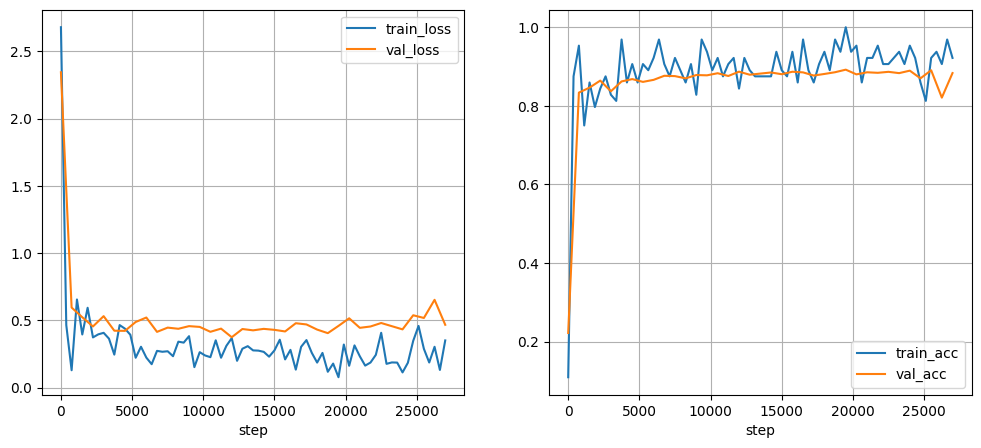

In [ ]:
# 注意：loss 不一定在 [0,1] 范围内，纵坐标由数据自动决定
def plot_learning_curves(record_dict, sample_step):
    """绘制训练/验证的损失和准确率学习曲线。

    有无 AlphaDropout 的对比效果可在此曲线中观察：
    加入 dropout 后训练准确率可能略低，但训练/验证曲线差距（过拟合程度）应减小。

    参数:
        record_dict (dict): training() 返回的记录，包含 'train' 和 'val'
        sample_step (int): 训练曲线降采样间隔，默认 500
    """
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    # pd.DataFrame 将记录列表转为表格；set_index("step") 以步数为行索引
    # iloc[::sample_step]: 每隔 sample_step 行取一个点，降低绘图密度
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")
    # 验证记录量少（每 epoch 一条），无需降采样

    fig_num = len(train_df.columns)   # int: 指标数量（'loss', 'acc' 共 2 个）
    fig, axs = plt.subplots(1, fig_num, figsize=(6 * fig_num, 5))
    # 创建 1 行 2 列子图，每个子图宽 6 英寸，高 5 英寸

    for idx, item in enumerate(train_df.columns):  # 遍历 'loss', 'acc'
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        # 绘制训练曲线（降采样后）
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        # 叠加验证曲线，对比训练/验证差距（判断 dropout 的正则化效果）
        axs[idx].grid()              # 添加网格线
        axs[idx].legend()            # 显示图例
        axs[idx].set_xlabel("step")  # 横轴标签（全局步数）

    plt.show()

plot_learning_curves(record, sample_step)  # 每隔len(train_loader)//2步取一个训练数据点

## 五、实验评估与总结

### 5.1 加载最佳 Checkpoint 并最终评估

In [13]:
# 推理时 AlphaDropout 的丢弃概率 p 自动变为 0（通过 model.eval() 触发）
# 即推理阶段所有神经元均参与计算，dropout 只在训练时起正则化作用
# 通过引入 dropout，一定程度上缓解了过拟合问题

# 加载训练过程中保存的最优 Checkpoint
model.load_state_dict(
    torch.load(
        os.path.join("model_checkpoints","selu+lecun+AlphaDropout","selu+lecun+AlphaDropout_best.ckpt"),  # str: 最优模型权重文件路径
        weights_only=True,                 # bool: 安全模式，只加载张量权重
        map_location="cpu"                 # str: 将权重统一映射到 CPU，避免设备不匹配
    )
)
# load_state_dict: 将保存的权重赋给模型对应参数（就地修改，无返回值）

model.eval()   # 切换评估模式：AlphaDropout 停用，BatchNorm（若有）使用运行统计

# 在验证集（FashionMNIST 测试集）上计算最终性能
loss, acc = evaluating(model, val_loader, loss_fct)
# 返回 (float, float): (平均损失, 准确率)
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")
# 与无 dropout 的 DNN 对比，dropout 通过防止过拟合可能带来更好的泛化性能

loss:     0.4588
accuracy: 0.8920
